[Bilgi] Otomatik grup kolonu üretildi: __group__ (benzersiz grup sayısı: 124)
Satır: 199 | Grup sayısı: 124
   __group__    H   dS
0          1  5.0  8.2
1         66  5.0  7.8
2          2  5.0  7.5
3          4  5.0  7.4
4          5  5.0  8.6

Pooled FE-OLS n* = 0.9129
Cluster-bootstrap 95% CI for n: 0.811 – 1.053

Pooled n (equal-alloy weighted) = 0.9008 vs unweighted 0.9129 |Δn|=0.0120

Field-agnosticity FE-test: slope(beta_after) in log(dS_ref) ~ log(H) = 0.0000 (≈0 beklenir)
Secondary (no-FE) diagnostics: Pearson r=0.179, Spearman ρ=0.190, log-slope=0.247 (tasarım-bias içerebilir)

ALAŞIM BAZINDA n_i (yalnızca ≥2 distinct H)
Alaşım sayısı: 25 | mean=0.9186 | median=0.8607 | SD=0.2932 | IQR=[0.7477,0.9004] | min–max=0.6128–1.8472
Pooled n*=0.9129 (CI 0.811–1.053) | within CI: 13/25 (52.0%)


C:\Users\kagan\AppData\Local\Temp\ipykernel_30868\246351828.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figür kaydedildi → per_alloy_n_distribution.png


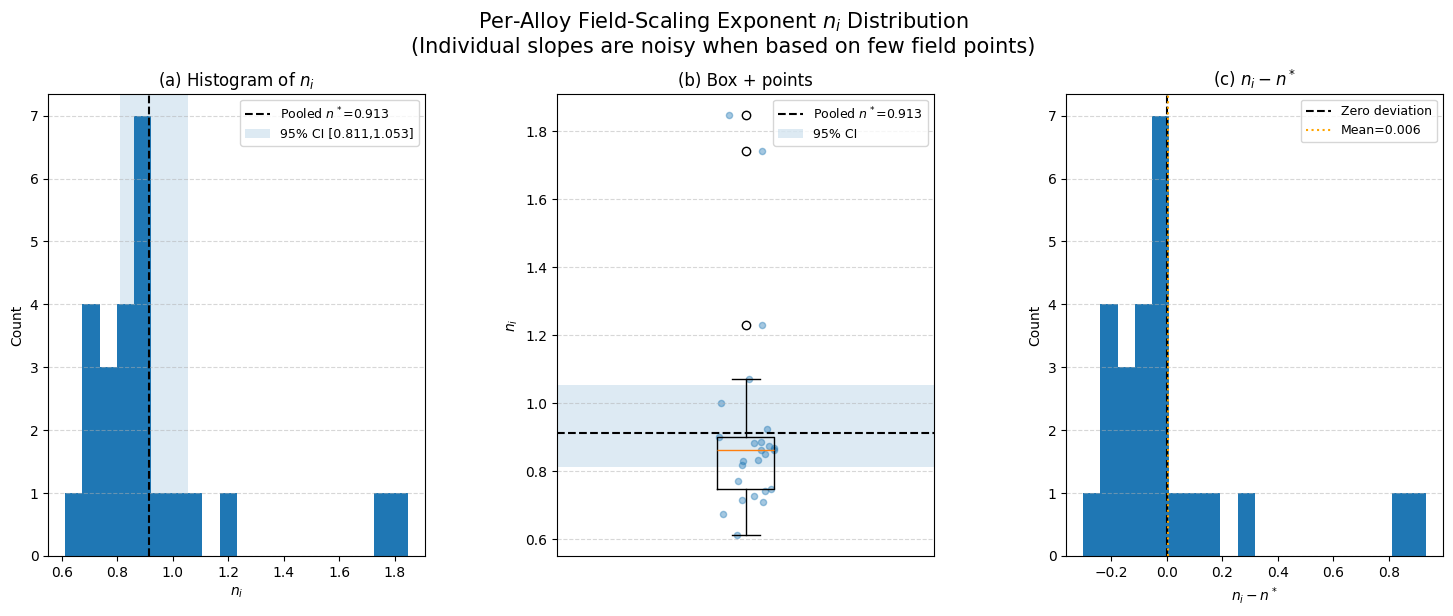


REVIEWER RESPONSE SUMMARY (copy-paste ready)
Only 25 alloys in our compiled dataset have ≥2 distinct field measurements; therefore, per-alloy slopes n_i are high-variance estimates (often based on 2–3 points). We thus estimate a statistically stable global exponent using a pooled fixed-effects regression (alloy intercepts + common slope), obtaining n* = 0.913 with a cluster-bootstrap 95% CI of [0.811, 1.053]. We additionally confirm robustness to uneven sampling via equal-alloy weighting (n_w = 0.901, |Δn| = 0.012). After normalization to ΔS_ref (Href=5.0 T), a fixed-effects regression of log(ΔS_ref) on log(H) yields slope = 0.000 (expected ≈ 0), confirming effective field-agnosticity when controlling for alloy identity.

Sanity-check: minimize |FE_beta_after| -> n ≈ 0.915 (primary) | minimize |raw log-slope| -> n ≈ 1.000 (secondary)
Figür kaydedildi → n_scan_targets.png


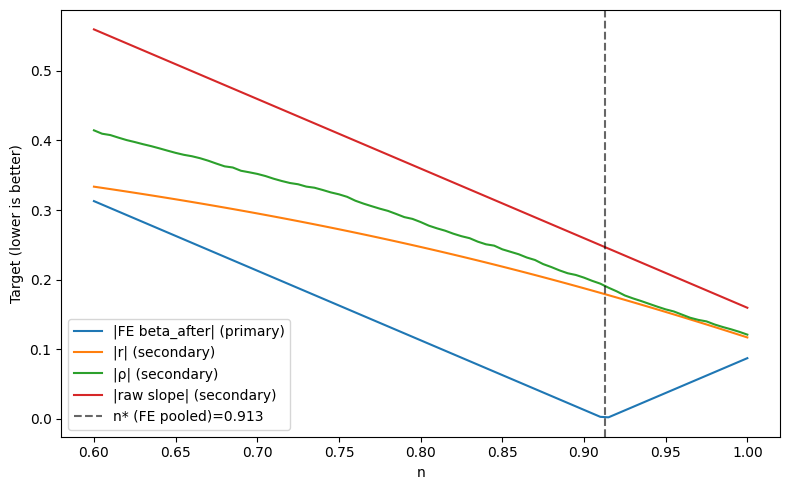


Href note: ΔS_ref rescales by a constant factor when Href changes, so correlation/slope diagnostics are invariant; FE beta_after is the meaningful test.
  Href=2.0T -> FE beta_after = 0.0000 (should be ~0)
  Href=3.0T -> FE beta_after = 0.0000 (should be ~0)
  Href=5.0T -> FE beta_after = 0.0000 (should be ~0)

Kaydedildi -> C:\Users\kagan\Downloads\COMPO_ONLY_dataset_2_with_dSref_Href5p0_n0p9129.csv

ÖZET
Yöntem     : Fixed-effects pooled log–log OLS (alloy intercepts + common slope).
n*         : 0.913 (cluster-bootstrap 95% CI: 0.811–1.053).
Robustness : equal-alloy weighted n_w=0.901 (|Δn|=0.0120).
Field test : FE beta_after (log dS_ref ~ log H) = 0.000 (≈0 beklenir).
n_i note   : Only 25 alloys have ≥2 distinct H; per-alloy slopes are noisy; 52.0% within pooled CI.
Output CSV : C:\Users\kagan\Downloads\COMPO_ONLY_dataset_2_with_dSref_Href5p0_n0p9129.csv

Sensitivity check (fixed n values):
 n_used  FE_beta_after
   0.85       0.062853
   0.90       0.012853
   0.95      -0.037147

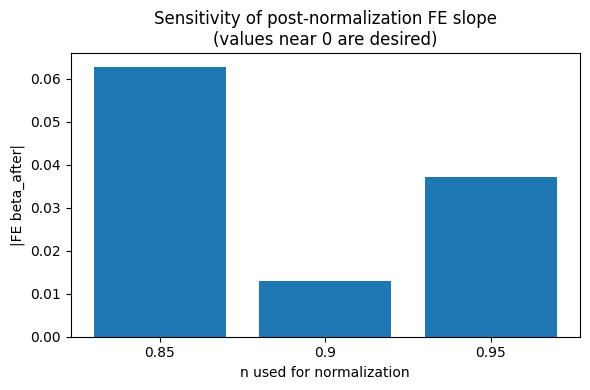

Figür kaydedildi → fixed_n_sensitivity.png


In [1]:
# =============================================================================
# n (alan üssü) kestirimi ve dS_ref üretimi — pooled log–log OLS + grup bootstrap
# + alloy-by-alloy n_i (yalnızca ≥2 farklı H olanlarda) + equal-alloy weighting
# + DOĞRU alan-agnostik test: dS_ref sonrası FIXED-EFFECTS slope(beta_after) ~ 0
# + Href notu: korelasyon/slope metrikleri ölçek-invariant (Href çarpanı), bu yüzden FE-test esas
# (statsmodels YOK; yalnızca numpy/pandas/matplotlib kullanır)
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---------------- 0) AYARLAR ----------------
DATA_PATH        = r"C:\Users\kagan\Downloads\COMPO_ONLY_dataset_2.csv"
H_REF            = 5.0
B_BOOT           = 2000
RNG_SEED         = 123
DO_PER_GROUP_N   = True   # 3 panelli n_i figürü
DO_WEIGHTED_N    = True   # equal-alloy weighting n
DO_SANITY_CHECK  = True   # n taraması (FE-test ile birlikte raporlanır)
SAVE_FIGS        = True
OUT_SUFFIX       = "_with_dSref"
FIG1_PATH        = "per_alloy_n_distribution.png"
FIG2_PATH        = "n_scan_targets.png"
# (Opsiyonel) Href listesi: yalnızca dS_ref sayısal ölçeği değişir; corr/slope aynı kalır -> FE-test kullan
HREF_LIST        = [2.0, 3.0, 5.0]

# ---------------- 1) VERİYİ YÜKLE & TEMİZLE ----------------
df = pd.read_csv(DATA_PATH)
if "dS" not in df.columns or "H" not in df.columns:
    raise RuntimeError("CSV'de 'dS' ve/veya 'H' sütunu bulunamadı.")
df["dS"] = pd.to_numeric(df["dS"], errors="coerce")
df["H"]  = pd.to_numeric(df["H"],  errors="coerce")
df = df.dropna(subset=["dS","H"]).copy()
df = df[(df["dS"] > 0) & (df["H"] > 0)].copy()

# ---------------- 2) GRUP (ALAŞIM) KOLONUNU BUL / ÜRET ----------------
GROUP_CANDIDATES = ["composition","Composition","alloy_id","Alloy_ID","alloy","Alloy","formula","Formula","comp","Comp"]
GROUP_COL = next((c for c in GROUP_CANDIDATES if c in df.columns), None)
if GROUP_COL is None:
    exclude = {"dS","H","RC","is_RC_missing","Tc","TC"}
    comp_cols = [c for c in df.columns if c not in exclude]
    comp_num = df[comp_cols].select_dtypes(include=[np.number]).copy()
    if comp_num.shape[1] == 0:
        print("[UYARI] Kompozisyonu temsil eden sayısal sütun bulunamadı. Her satır ayrı grup sayılacak.")
        df["__group__"] = np.arange(len(df)); GROUP_COL = "__group__"
    else:
        comp_sig = comp_num.round(6).astype(str).agg("|".join, axis=1)
        df["__group__"] = pd.factorize(comp_sig, sort=True)[0]; GROUP_COL = "__group__"
        print(f"[Bilgi] Otomatik grup kolonu üretildi: {GROUP_COL} (benzersiz grup sayısı: {df[GROUP_COL].nunique()})")
else:
    print(f"[Bilgi] Grup kolonu bulundu: '{GROUP_COL}'")

# Log dönüşümleri
df["log_dS"] = np.log(df["dS"])
df["log_H"]  = np.log(df["H"])
print(f"Satır: {len(df)} | Grup sayısı: {df[GROUP_COL].nunique()}")
print(df[[GROUP_COL,"H","dS"]].head())

# ---------------- Yardımcılar (scipy yok) ----------------
def pearsonr_np(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    am = a - a.mean(); bm = b - b.mean()
    denom = am.std(ddof=1) * bm.std(ddof=1)
    return (am @ bm) / ((len(a)-1) * denom) if denom > 0 else 0.0

def spearmanr_rank(a, b):
    ar = pd.Series(a).rank(method="average").to_numpy()
    br = pd.Series(b).rank(method="average").to_numpy()
    return pearsonr_np(ar, br)

def build_fe_design(dataframe, group_col):
    cats = dataframe[group_col].astype("category")
    D = pd.get_dummies(cats, drop_first=False).to_numpy()  # FE intercepts
    X = np.hstack([D, dataframe["log_H"].to_numpy().reshape(-1,1)])  # last col is log_H
    return X

# ---------------- 3) FE POOLED OLS: log dS = alpha_group + n log H ----------------
def pooled_slope_n(dataframe, group_col):
    X = build_fe_design(dataframe, group_col)
    y = dataframe["log_dS"].to_numpy()
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(beta[-1])

n_hat = pooled_slope_n(df, GROUP_COL)
print(f"\nPooled FE-OLS n* = {n_hat:.4f}")

# ---------------- 4) GRUP-BOOTSTRAP ile %95 GA (cluster bootstrap on alloys) --------------
rng = np.random.default_rng(RNG_SEED)
groups = df[GROUP_COL].unique()
boots = []
for _ in range(B_BOOT):
    samp = rng.choice(groups, size=len(groups), replace=True)
    ddb = pd.concat([df[df[GROUP_COL]==g] for g in samp], ignore_index=True)
    boots.append(pooled_slope_n(ddb, GROUP_COL))
boots = np.array(boots, float)
ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
print(f"Cluster-bootstrap 95% CI for n: {ci_lo:.3f} – {ci_hi:.3f}")

# ---------------- 3c) Equal-alloy weighting pooled n (opsiyonel) ----------------
def pooled_slope_n_weighted(dataframe, group_col):
    X = build_fe_design(dataframe, group_col)
    y = dataframe["log_dS"].to_numpy()
    counts = dataframe[group_col].map(dataframe[group_col].value_counts()).to_numpy()
    w = 1.0 / counts
    sw = np.sqrt(w)
    Xw = X * sw[:, None]; yw = y * sw
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    return float(beta[-1])

if DO_WEIGHTED_N:
    n_hat_w = pooled_slope_n_weighted(df, GROUP_COL)
    diff_w = abs(n_hat_w - n_hat)
    print(f"\nPooled n (equal-alloy weighted) = {n_hat_w:.4f} vs unweighted {n_hat:.4f} |Δn|={diff_w:.4f}")

# ---------------- 5) dS_ref üret (Href) ----------------
df["dS_ref"] = df["dS"] * (H_REF/df["H"])**n_hat
df["dS_ref"] = np.clip(df["dS_ref"].to_numpy(), 1e-300, None)
df["log_dSref"] = np.log(df["dS_ref"])

# ---------------- 5a) DOĞRU alan-agnostik test: FE sonrası beta_after ~ 0 ----------------
def fe_slope_on_logH_from_ylog(y_log, dataframe, group_col):
    X = build_fe_design(dataframe, group_col)
    beta, *_ = np.linalg.lstsq(X, y_log, rcond=None)
    return float(beta[-1])

beta_after = fe_slope_on_logH_from_ylog(df["log_dSref"].to_numpy(), df, GROUP_COL)
print(f"\nField-agnosticity FE-test: slope(beta_after) in log(dS_ref) ~ log(H) = {beta_after:.4f} (≈0 beklenir)")

# (İkincil, ham metrikler — NOT: alloy kimliği kontrol edilmediği için yanıltıcı olabilir)
rP_raw = pearsonr_np(df["dS_ref"], df["H"])
rS_raw = spearmanr_rank(df["dS_ref"], df["H"])
slope_raw = np.polyfit(np.log(df["H"]), np.log(df["dS_ref"]), 1)[0]
print(f"Secondary (no-FE) diagnostics: Pearson r={rP_raw:.3f}, Spearman ρ={rS_raw:.3f}, log-slope={slope_raw:.3f} (tasarım-bias içerebilir)")

# ---------------- 3b) Alloy-by-alloy n_i + 3 panelli figür (opsiyonel) ----------------
def per_group_slopes(dataframe, group_col, min_unique_H=2):
    rows = []
    for g, dfg in dataframe.groupby(group_col):
        if dfg["H"].nunique() < min_unique_H:
            continue
        x = np.log(dfg["H"].to_numpy()); y = np.log(dfg["dS"].to_numpy())
        n_i = np.polyfit(x, y, 1)[0]
        rows.append((g, float(n_i), int(len(dfg)), int(dfg["H"].nunique())))
    return pd.DataFrame(rows, columns=[group_col,"n_i","n_obs","n_unique_H"])

ng = pd.DataFrame(); n_vals = np.array([], dtype=float); pct_within = np.nan
if DO_PER_GROUP_N:
    ng = per_group_slopes(df, GROUP_COL)
    if len(ng) == 0:
        print("\n[UYARI] Per-alloy n_i için ≥2 farklı H olan grup yok.")
    else:
        n_vals = ng["n_i"].to_numpy()
        ng["n_i_minus_pooled"] = ng["n_i"] - n_hat
        deviations = n_vals - n_hat
        within_ci = int(np.sum((n_vals >= ci_lo) & (n_vals <= ci_hi)))
        pct_within = within_ci / len(n_vals) * 100.0
        print("\n" + "="*65)
        print("ALAŞIM BAZINDA n_i (yalnızca ≥2 distinct H)")
        print("="*65)
        print(f"Alaşım sayısı: {len(n_vals)} | mean={n_vals.mean():.4f} | median={np.median(n_vals):.4f} | SD={n_vals.std(ddof=1):.4f} | IQR=[{np.percentile(n_vals,25):.4f},{np.percentile(n_vals,75):.4f}] | min–max={n_vals.min():.4f}–{n_vals.max():.4f}")
        print(f"Pooled n*={n_hat:.4f} (CI {ci_lo:.3f}–{ci_hi:.3f}) | within CI: {within_ci}/{len(n_vals)} ({pct_within:.1f}%)")
        fig = plt.figure(figsize=(18,6)); fig.suptitle("Per-Alloy Field-Scaling Exponent $n_i$ Distribution\n(Individual slopes are noisy when based on few field points)", fontsize=15, y=1.02)
        gs = gridspec.GridSpec(1,3,wspace=0.35)
        ax1 = fig.add_subplot(gs[0]); ax1.hist(n_vals, bins=20); ax1.axvline(n_hat, color="k", ls="--", label=f"Pooled $n^*$={n_hat:.3f}"); ax1.axvspan(ci_lo, ci_hi, alpha=0.15, label=f"95% CI [{ci_lo:.3f},{ci_hi:.3f}]"); ax1.set_title("(a) Histogram of $n_i$"); ax1.set_xlabel("$n_i$"); ax1.set_ylabel("Count"); ax1.legend(fontsize=9); ax1.grid(axis="y", ls="--", alpha=0.5)
        ax2 = fig.add_subplot(gs[1]); ax2.boxplot(n_vals, vert=True); jitter = np.random.default_rng(42).uniform(-0.08,0.08,size=len(n_vals)); ax2.scatter(1+jitter, n_vals, alpha=0.4, s=20); ax2.axhline(n_hat, color="k", ls="--", label=f"Pooled $n^*$={n_hat:.3f}"); ax2.axhspan(ci_lo, ci_hi, alpha=0.15, label="95% CI"); ax2.set_title("(b) Box + points"); ax2.set_ylabel("$n_i$"); ax2.set_xticks([]); ax2.legend(fontsize=9); ax2.grid(axis="y", ls="--", alpha=0.5)
        ax3 = fig.add_subplot(gs[2]); ax3.hist(deviations, bins=20); ax3.axvline(0, color="k", ls="--", label="Zero deviation"); ax3.axvline(deviations.mean(), color="orange", ls=":", label=f"Mean={deviations.mean():.3f}"); ax3.set_title("(c) $n_i - n^*$"); ax3.set_xlabel("$n_i-n^*$"); ax3.set_ylabel("Count"); ax3.legend(fontsize=9); ax3.grid(axis="y", ls="--", alpha=0.5)
        plt.tight_layout()
        if SAVE_FIGS:
            plt.savefig(FIG1_PATH, dpi=300, bbox_inches="tight"); print(f"Figür kaydedildi → {FIG1_PATH}")
        plt.show()
        print("\n" + "="*65)
        print("REVIEWER RESPONSE SUMMARY (copy-paste ready)")
        print("="*65)
        print(f"Only {len(n_vals)} alloys in our compiled dataset have ≥2 distinct field measurements; therefore, per-alloy slopes n_i are high-variance estimates (often based on 2–3 points). We thus estimate a statistically stable global exponent using a pooled fixed-effects regression (alloy intercepts + common slope), obtaining n* = {n_hat:.3f} with a cluster-bootstrap 95% CI of [{ci_lo:.3f}, {ci_hi:.3f}]. We additionally confirm robustness to uneven sampling via equal-alloy weighting (n_w = {n_hat_w:.3f}, |Δn| = {abs(n_hat_w-n_hat):.3f}). After normalization to ΔS_ref (Href={H_REF:.1f} T), a fixed-effects regression of log(ΔS_ref) on log(H) yields slope = {beta_after:.3f} (expected ≈ 0), confirming effective field-agnosticity when controlling for alloy identity.")

# ---------------- 6) n taraması (opsiyonel): hedef = |beta_after(n)| + ikincil metrikler ----------------
if DO_SANITY_CHECK:
    grid = np.linspace(0.60, 1.00, 81)
    recs = []
    for n in grid:
        Sref_n = np.clip((df["dS"] * (H_REF/df["H"])**n).to_numpy(), 1e-300, None)
        ylog = np.log(Sref_n)
        beta_fe = fe_slope_on_logH_from_ylog(ylog, df, GROUP_COL)  # esas hedef
        rp = abs(pearsonr_np(Sref_n, df["H"]))
        rs = abs(spearmanr_rank(Sref_n, df["H"]))
        ls = abs(np.polyfit(np.log(df["H"]), np.log(Sref_n), 1)[0])
        recs.append((float(n), float(abs(beta_fe)), float(rp), float(rs), float(ls)))
    scan = pd.DataFrame(recs, columns=["n","|FE_beta_after|","|r_Pearson|","|rho_Spearman|","|log_slope|"])
    n_best_fe  = float(scan.loc[scan["|FE_beta_after|"].idxmin(), "n"])
    n_best_raw = float(scan.loc[scan["|log_slope|"].idxmin(), "n"])
    print(f"\nSanity-check: minimize |FE_beta_after| -> n ≈ {n_best_fe:.3f} (primary) | minimize |raw log-slope| -> n ≈ {n_best_raw:.3f} (secondary)")
    plt.figure(figsize=(8,5))
    plt.plot(scan["n"], scan["|FE_beta_after|"], label="|FE beta_after| (primary)")
    plt.plot(scan["n"], scan["|r_Pearson|"], label="|r| (secondary)")
    plt.plot(scan["n"], scan["|rho_Spearman|"], label="|ρ| (secondary)")
    plt.plot(scan["n"], scan["|log_slope|"], label="|raw slope| (secondary)")
    plt.axvline(n_hat, color="k", ls="--", alpha=0.6, label=f"n* (FE pooled)={n_hat:.3f}")
    plt.xlabel("n"); plt.ylabel("Target (lower is better)")
    plt.legend(); plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG2_PATH, dpi=300, bbox_inches="tight"); print(f"Figür kaydedildi → {FIG2_PATH}")
    plt.show()

# ---------------- 7) Href listesi için FE-test (bilgilendirici) ----------------
print("\nHref note: ΔS_ref rescales by a constant factor when Href changes, so correlation/slope diagnostics are invariant; FE beta_after is the meaningful test.")
for href in HREF_LIST:
    Sref = np.clip((df["dS"] * (href/df["H"])**n_hat).to_numpy(), 1e-300, None)
    beta_fe = fe_slope_on_logH_from_ylog(np.log(Sref), df, GROUP_COL)
    print(f"  Href={href:.1f}T -> FE beta_after = {beta_fe:.4f} (should be ~0)")

# ---------------- 8) CSV kaydet ----------------
root, ext = os.path.splitext(DATA_PATH)
n_tag = f"{n_hat:.4f}".replace(".","p")
href_tag = f"{H_REF:.1f}".replace(".","p")
out_csv = root + f"{OUT_SUFFIX}_Href{href_tag}_n{n_tag}.csv"
df.to_csv(out_csv, index=False)
print("\nKaydedildi ->", out_csv)

# ---------------- 9) ÖZET ----------------
print("\n" + "="*65); print("ÖZET"); print("="*65)
print(f"Yöntem     : Fixed-effects pooled log–log OLS (alloy intercepts + common slope).")
print(f"n*         : {n_hat:.3f} (cluster-bootstrap 95% CI: {ci_lo:.3f}–{ci_hi:.3f}).")
if DO_WEIGHTED_N:
    print(f"Robustness : equal-alloy weighted n_w={n_hat_w:.3f} (|Δn|={abs(n_hat_w-n_hat):.4f}).")
print(f"Field test : FE beta_after (log dS_ref ~ log H) = {beta_after:.3f} (≈0 beklenir).")
if DO_PER_GROUP_N and len(ng) > 0:
    print(f"n_i note   : Only {len(n_vals)} alloys have ≥2 distinct H; per-alloy slopes are noisy; {pct_within:.1f}% within pooled CI.")
print(f"Output CSV : {out_csv}")
# ---------------- 10) Ek duyarlılık: n sabit seti için FE beta_after ----------------
N_SENS_LIST = [0.85, 0.90, 0.95]
sens_rows = []
for n0 in N_SENS_LIST:
    Sref0 = np.clip((df["dS"] * (H_REF/df["H"])**n0).to_numpy(), 1e-300, None)
    beta0 = fe_slope_on_logH_from_ylog(np.log(Sref0), df, GROUP_COL)
    sens_rows.append((n0, beta0))
sens_df = pd.DataFrame(sens_rows, columns=["n_used","FE_beta_after"])
print("\nSensitivity check (fixed n values):")
print(sens_df.to_string(index=False))

plt.figure(figsize=(6,4))
plt.bar([str(x) for x in sens_df["n_used"]], np.abs(sens_df["FE_beta_after"].to_numpy()))
plt.xlabel("n used for normalization")
plt.ylabel("|FE beta_after|")
plt.title("Sensitivity of post-normalization FE slope\n(values near 0 are desired)")
plt.tight_layout()
plt.savefig("fixed_n_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figür kaydedildi → fixed_n_sensitivity.png")